In [ ]:
#from google.colab import drive

In [ ]:
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

class InriaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Чтение трехканального спутникового снимка
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Чтение одноканальной маски застройки
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Перевод маски в бинарный формат (0 или 1)
        mask = (mask > 127).astype(np.float32)

        # Синхронное применение кадрирования и нормализации
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Добавление канала размерности для PyTorch, чтобы получить [1, H, W]
        if isinstance(mask, torch.Tensor):
            mask = mask.unsqueeze(0)
        else:
            mask = np.expand_dims(mask, axis=0)

        return image, mask

# Подготовка путей к локальным файлам в Colab
dataset_dir = Path('/content/drive/MyDrive/Inria_Project/unzip_full_archive/train')
images_dir = dataset_dir / 'images'
masks_dir = dataset_dir / 'gt'

# Сбор путей и обязательная жесткая сортировка для исключения рассинхронизации
all_img_paths = sorted([str(p) for p in images_dir.iterdir() if p.is_file()])
all_msk_paths = sorted([str(p) for p in masks_dir.iterdir() if p.is_file()])

# Разделение папки train на изолированное обучение и валидацию (85% на 15%)
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    all_img_paths,
    all_msk_paths,
    test_size=0.15,
    random_state=42
)

# Определение трансформаций для обучения (случайный кроп 512x512)
train_transform = A.Compose([
    A.RandomCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Определение трансформаций для валидации (фиксированный центральный кроп)
val_transform = A.Compose([
    A.CenterCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Создание экземпляров класса Dataset для обоих потоков
train_dataset = InriaDataset(image_paths=train_imgs, mask_paths=train_msks, transform=train_transform)
val_dataset = InriaDataset(image_paths=val_imgs, mask_paths=val_msks, transform=val_transform)

# Финальное создание загрузчиков батчей для нейросети
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, drop_last=False)

# Проверочный прогон для подтверждения работоспособности пайплайна
test_images, test_masks = next(iter(train_loader))
print(f"Успех! Размерность батча изображений: {test_images.shape}")
print(f"Успех! Размерность батча масок: {test_masks.shape}")

In [ ]:
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Фиксируем пути к локальным директориям
dataset_dir = Path('/content/drive/MyDrive/Inria_Project/unzip_full_archive/train')
images_dir = dataset_dir / 'images'
masks_dir = dataset_dir / 'gt'

# Собираем файлы и применяем строгую сортировку для идеального маппинга
all_img_paths = sorted([str(p) for p in images_dir.iterdir() if p.is_file()])
all_msk_paths = sorted([str(p) for p in masks_dir.iterdir() if p.is_file()])

# Разделяем пути на train и val в пропорции 85/15 с фиксацией случайного сида
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    all_img_paths,
    all_msk_paths,
    test_size=0.15,
    random_state=42
)

# Для обучающей выборки используем случайное кадрирование и нормализацию
train_transform = A.Compose([
    A.RandomCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Для валидационной выборки используем центральное кадрирование, чтобы оценка была стабильной
val_transform = A.Compose([
    A.CenterCrop(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Инициализируем два отдельных экземпляра класса Dataset
train_dataset = InriaDataset(image_paths=train_imgs, mask_paths=train_msks, transform=train_transform)
val_dataset = InriaDataset(image_paths=val_imgs, mask_paths=val_msks, transform=val_transform)

# Создаем финальные DataLoader. Для валидации перемешивание (shuffle) не требуется
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, drop_last=False)

print(f"Количество снимков для обучения: {len(train_imgs)}")
print(f"Количество снимков для валидации: {len(val_imgs)}")

Количество снимков для обучения: 153
Количество снимков для валидации: 27


In [ ]:
!pip install segmentation_models_pytorch

In [ ]:
import torch
import segmentation_models_pytorch as smp

# 1. Определение устройства вычислений
# Обязательно убедись, что в Colab включен GPU (Среда выполнения -> Сменить среду выполнения -> T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# 2. Инициализация модели U-Net
model = smp.Unet(
    encoder_name='resnet34',        # Легкий и эффективный энкодер
    encoder_weights='imagenet',     # Предобученные веса для быстрого схождения
    in_channels=3,                  # Количество каналов на входе (RGB снимки)
    classes=1                       # Количество каналов на выходе (бинарная маска)
)

# Перенос весов модели в память видеокарты
model = model.to(device)

Используемое устройство: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import math
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# Шаг 1: Определение нового, усиленного геометрического пайплайна аугментаций
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=45,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    A.CropNonEmptyMaskIfExists(height=512, width=512, p=1.0),
    ToTensorV2()
])

# Примечание: Для val_loader обязательно оставляем старый стабильный val_transform с CenterCrop!

class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode='binary')
        self.bce_weight = bce_weight

    def forward(self, outputs, masks):
        bce_loss = self.bce(outputs, masks)
        dice_loss = self.dice(outputs, masks)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

# Шаг 2: Полный сброс архитектуры к базовым весам ImageNet
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1
)
model = model.to(device)

# Шаг 3: Настройка оптимизации на расширенную дистанцию 60 эпох
criterion = DiceBCELoss(bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 60
train_losses = []
val_losses = []

# Переменная T_max автоматически принимает значение 60, растягивая косинус
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
best_val_loss = math.inf

print("Запуск масштабного эксперимента: U-Net + Усиленный D4 пайплайн + CosineAnnealingLR (60 эпох)...")

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{num_epochs} [Обучение]")
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_bar.set_postfix({'loss': loss.item()})

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Эпоха {epoch+1}/{num_epochs} [Валидация]")
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item()
            val_bar.set_postfix({'val_loss': loss.item()})

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # Сохранение промежуточных бэкапов каждые 5 эпох с новым именем
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'/content/drive/MyDrive/Inria_Project/unet_cosine_60ep_epoch_{epoch+1}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f"[*] Резервная копия расширенного эксперимента сохранена: {checkpoint_path}")

    # Фиксация абсолютного рекорда для конфигурации на 60 эпох
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_path = '/content/drive/MyDrive/Inria_Project/unet_cosine_60ep_best.pth'
        torch.save(model.state_dict(), best_model_path)
        print(f"[!] Улучшение Val Loss на 60 эпохах! Рекорд: {best_val_loss:.4f}. Лучшие веса сохранены.")

    print(f"Итог эпохи {epoch+1}: Train Loss = {epoch_train_loss:.4f} | Val Loss = {epoch_val_loss:.4f}")

    scheduler.step()
    print(f" Скорость обучения для следующей эпохи: {scheduler.get_last_lr()[0]:.6f}\n")

# Финальное сохранение весов по окончании всей дистанции
torch.save(model.state_dict(), '/content/drive/MyDrive/Inria_Project/unet_cosine_60ep_final.pth')
print("Расширенный эксперимент на 60 эпох успешно завершен. Веса полностью изолированы.")

Ошибка лучшей модели: 0.1654

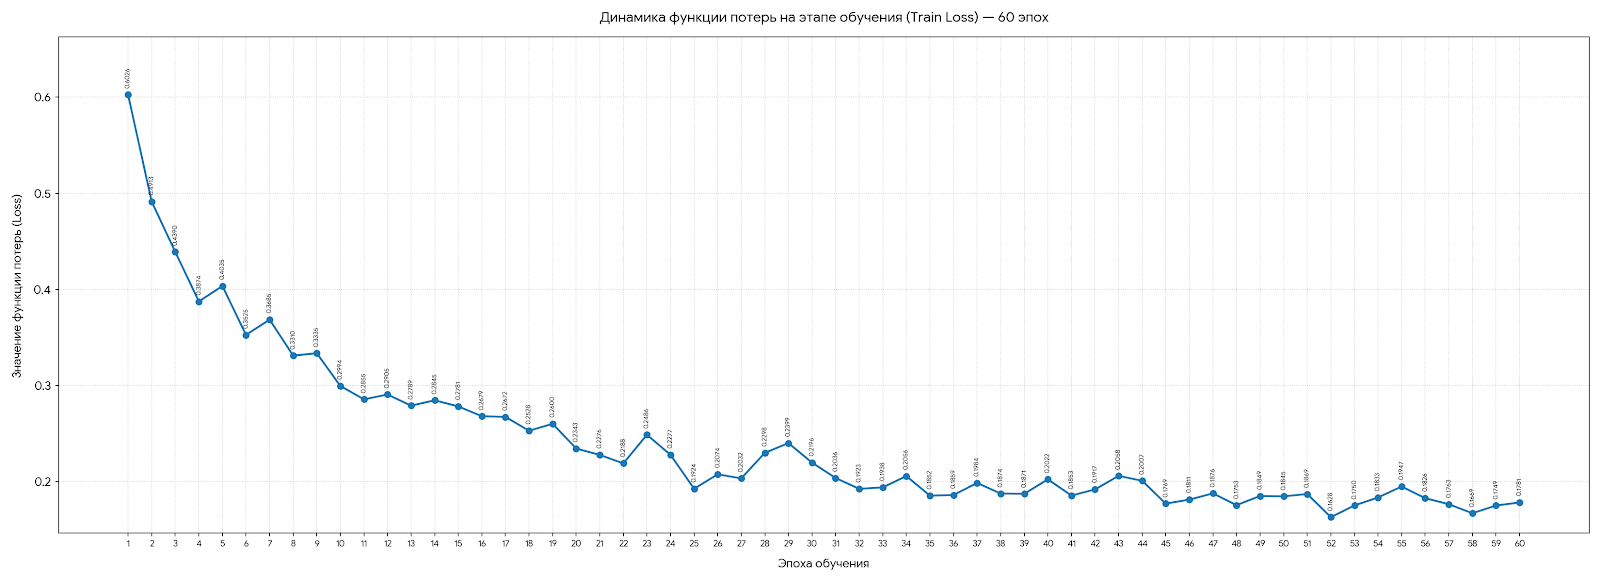